
==================== Testing Models on CAD.csv ====================
Finished Logistic Regression: AUC = 0.8092
Finished KNN: AUC = 0.7369
Finished Decision Tree: AUC = 0.5954
Finished Random Forest: AUC = 0.7690

Model Comparison Table (D1):
                 Model  Accuracy  Precision    Recall  F1-Score       AUC
0  Logistic Regression  0.785410   0.829468  0.879704  0.851797  0.809179
3        Random Forest  0.749016   0.782305  0.897886  0.835601  0.769012
1                  KNN  0.755683   0.793651  0.888795  0.838207  0.736865
2        Decision Tree  0.666995   0.769127  0.764059  0.766108  0.595428

==================== Generalization Test ====================
Generalization Performance (D1 -> D2):
AUC Score: 0.7018

Classification Report (Generalization):
              precision    recall  f1-score   support

           0       0.49      0.39      0.44      2002
           1       0.76      0.82      0.79      4609

    accuracy                           0.69      6611
   macro

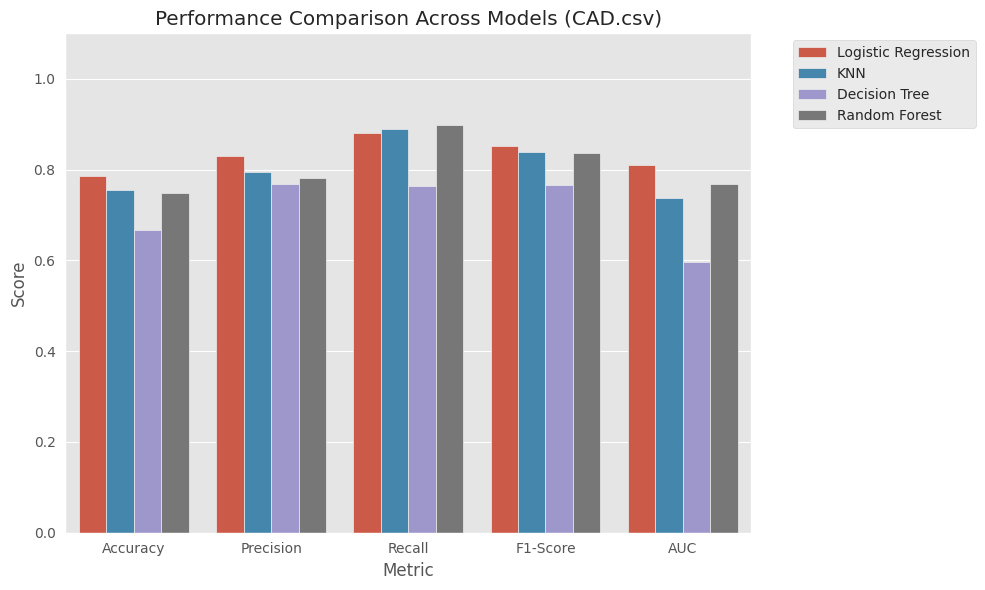

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 6.1 Importing Additional Libraries

from sklearn.model_selection import StratifiedKFold, cross_validate

from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.metrics import classification_report, roc_auc_score

# 6.2 Adjusting Settings

RANDOM_STATE = 42

plt.style.use('ggplot')



def load_and_preprocess():

    """Helper to load and harmonize datasets based on previous steps."""

    try:

        df_cad = pd.read_csv('CAD.csv')

        df_fullage = pd.read_csv('DataClean-fullage.csv')

    except FileNotFoundError:

        print("CSV files not found. Please ensure CAD.csv and DataClean-fullage.csv are in the directory.")

        return None, None



    # Harmonize Targets

    df_cad['Target'] = df_cad['Cath'].apply(lambda x: 1 if x in ['Cad', 'cad'] else 0)

    df_fullage['Target'] = df_fullage['cad']



    # Harmonize Categorical (Simplified)

    for df in [df_cad, df_fullage]:

        for col in df.columns:

            if df[col].dtype == 'object':

                df[col] = df[col].map({'Y': 1, 'N': 0, 'y': 1, 'n': 0, 'Male': 1, 'Fmale': 0, 'M': 1, 'F': 0}).fillna(df[col])



    return df_cad, df_fullage

# 6.3 Defining models that will be used and compared

def get_ml_results(X, y, title="Primary Dataset (D1)"):

    """Runs the requested ML models and returns evaluation metrics."""

    print(f"\n{'='*20} Testing Models on {title} {'='*20}")



    # Updated model dictionary based on your request

    models = {

        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),

        'KNN': KNeighborsClassifier(n_neighbors=5),

        'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),

        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)

    }



    scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)



    results_summary = []



    for name, model in models.items():

        # Create pipeline for scaling (especially important for KNN and Logistic Regression)

        pipeline = Pipeline([

            ('scaler', StandardScaler()),

            ('clf', model)

        ])



        # Cross-validation

        cv_results = cross_validate(pipeline, X, y, cv=cv, scoring=scoring)



        summary = {

            'Model': name,

            'Accuracy': cv_results['test_accuracy'].mean(),

            'Precision': cv_results['test_precision'].mean(),

            'Recall': cv_results['test_recall'].mean(),

            'F1-Score': cv_results['test_f1'].mean(),

            'AUC': cv_results['test_roc_auc'].mean()

        }

        results_summary.append(summary)

        print(f"Finished {name}: AUC = {summary['AUC']:.4f}")



    return pd.DataFrame(results_summary)

#6.4 Machine Learning and comparing

def main():

    df_cad, df_fullage = load_and_preprocess()

    if df_cad is None: return



    # --- 1. Train on Dataset 1 (D1 - CAD.csv) ---

    # Note: Column names must match your CSV exactly (e.g., 'CR' vs 'Cr')

    features_d1 = ['Age', 'Sex', 'BMI', 'DM', 'HTN', 'Current Smoker', 'EX-Smoker', 'FH',

                    'FBS', 'CR', 'TG', 'LDL', 'HDL', 'HB', 'WBC', 'EF-TTE']



    # Pre-cleaning for ML

    X_d1 = df_cad[features_d1].apply(pd.to_numeric, errors='coerce').fillna(df_cad[features_d1].median())

    y_d1 = df_cad['Target']



    d1_results = get_ml_results(X_d1, y_d1, "CAD.csv")

    print("\nModel Comparison Table (D1):")

    print(d1_results.sort_values(by='AUC', ascending=False))



    # --- 2. Generalization Test (Train on D1, Test on D2) ---

    print("\n" + "="*20 + " Generalization Test " + "="*20)



    # Common features across both datasets

    common_d1 = ['Age', 'Sex', 'DM', 'HTN', 'Current Smoker']

    common_d2 = ['age', 'gender', 'diabetes', 'hypertension', 'smoking']



    X_train = df_cad[common_d1].apply(pd.to_numeric, errors='coerce').fillna(df_cad[common_d1].median())

    y_train = df_cad['Target']



    X_test = df_fullage[common_d2].apply(pd.to_numeric, errors='coerce').fillna(df_fullage[common_d2].median())

    y_test = df_fullage['Target']



    # Standardize column names for the model to accept X_test

    X_train.columns = ['age', 'sex', 'diabetes', 'hypertension', 'smoking']

    X_test.columns = ['age', 'sex', 'diabetes', 'hypertension', 'smoking']



    # Use Random Forest for Generalization

    gen_pipeline = Pipeline([

        ('scaler', StandardScaler()),

        ('clf', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE))

    ])



    gen_pipeline.fit(X_train, y_train)

    y_pred = gen_pipeline.predict(X_test)

    y_proba = gen_pipeline.predict_proba(X_test)[:, 1]



    gen_auc = roc_auc_score(y_test, y_proba)

    print(f"Generalization Performance (D1 -> D2):")

    print(f"AUC Score: {gen_auc:.4f}")

    print("\nClassification Report (Generalization):")

    print(classification_report(y_test, y_pred))



    # Visualization of Model Comparison

    plt.figure(figsize=(10, 6))

    melted_results = d1_results.melt(id_vars='Model', var_name='Metric', value_name='Score')

    sns.barplot(data=melted_results, x='Metric', y='Score', hue='Model')

    plt.title('Performance Comparison Across Models (CAD.csv)')

    plt.ylim(0, 1.1)

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()

    plt.show()



if __name__ == "__main__":

    main()